# Multiobjective Evolutionary Algorithm based on Decomposition
-- Uvini Balasuriya and Divya Ramachandran

All the imports

In [14]:
import pandas as pd
import numpy as np
from pymoo.problems import get_problem
import sklearn

Function for implementing moea-d

In [48]:
# Function to evaluate the problem
def evaluate(problem, x):
    """Evaluate the problem for a given input vector.
    
    problem: The problem instance from pymoo
    x: The input vector to evaluate
    """
    return problem.evaluate(x.reshape(1, -1))[0]


# Function to generate weights vectors
# MOEA-D relies on evenly distributed weight vectors to decompose the multi-objective problem into scalar subproblems.

def generate_weights(N, M):

    """
    Generate weight vectors for MOEA-D.
    N: Number of weight vectors (population size)
    M: Number of objectives
    """

    if M == 2:
        return np.array([[i/(N-1), 1 - i/(N-1)] for i in range(N)])
    else:
        # fallback random for higher dimensions
        W = np.random.rand(N, M)
        return W / W.sum(axis=1, keepdims=True)
    
    
# Neighbourhood function to find the closest weight vectors
def find_neighbors(W, T):
    """
    Find the T closest weight vectors for each weight vector in W.
    W: Weight vectors
    T: Number of neighbors
    """
    from sklearn.metrics import pairwise_distances
    distances = pairwise_distances(W)
    neighbors = np.argsort(distances, axis=1)[:, :T]
    return neighbors


# Iniitalize population
def initialize_population(problem, N):
    """
    Initialize the population for MOEA-D.
    """
    X = np.random.uniform(problem.xl, problem.xu, (N, problem.n_var))
    F = problem.evaluate(X)
    return X, F


# Initialize ideal point Z*
def initialize_ideal_point(F):
    """
    Initialize the ideal point Z* based on the initial population's objective values.
    F: Objective values of the initial population
    """
    return np.min(F, axis=0)


# Decomposition function to solve scalar subproblems
def g(f, w, z):
    """
    Tchebycheff decomposition function.

    f: objective vector of ONE solution (shape: M,)
    w: ONE weight vector (shape: M,)
    z: ideal point (shape: M,)

    returns: scalar value
    """
    # return np.max(w * np.abs(f - z)) 
    return np.max(np.maximum(w, 1e-6) * np.abs(f - z))


# Function to select parents for reproduction
def select_parents(i, B, N, delta):
    """
    Select parents for reproduction based on the neighborhood structure.
        i: Index of the current subproblem
        B: Neighborhood structure (list of neighbors for each subproblem)
        N: Total population size
        delta: Probability of selecting from the neighborhood
    """

    if np.random.rand() < delta:
        P = B[i]            # neighbors
    else:
        P = np.arange(N)    # whole population

    k, l = np.random.choice(P, 2, replace=False)
    return k, l


def variation(x1, x2, xl, xu):
    """
    x1, x2: parent solutions (1D arrays)
    xl, xu: lower/upper bounds (from problem)

    returns: offspring y
    """

    # Crossover (blend parents)
    alpha = np.random.rand()
    y = alpha * x1 + (1 - alpha) * x2

    # Mutation (add small noise)
    sigma = 0.03  # mutation strength (tune if needed)
    noise = sigma * (xu - xl) * np.random.randn(len(x1))
    y = y + noise

    # Clip to bounds
    y = np.clip(y, xl, xu)

    return y


def moead(problem, N=100, T=10, delta=0.9, max_gen=200):

    # Step 1: weights
    W = generate_weights(N, problem.n_obj)

    # Step 2: neighbors
    B = find_neighbors(W, T)

    # Step 3: population
    X, F = initialize_population(problem, N)

    # Step 4: ideal point
    z = initialize_ideal_point(F)

    # Step 5: main loop
    for gen in range(max_gen):

        for i in range(N):

            # parent selection
            k, l = select_parents(i, B, N, delta)

            # variation
            y = variation(X[k], X[l], problem.xl, problem.xu)

            # evaluation
            f_y = evaluate(problem, y)

            # update ideal point
            z = np.minimum(z, f_y)

            # update neighbors
            for j in B[i]:
                if g(f_y, W[j], z) <= g(F[j], W[j], z):
                    X[j] = y
                    F[j] = f_y

    return X, F

Execution Code

[[1.         0.03805823]
 [1.         0.03770797]
 [0.99354239 0.05314433]
 [0.9694455  0.06842957]
 [0.95318608 0.07600912]
 [0.93242915 0.08788706]
 [0.91135044 0.09646208]
 [0.85608909 0.10521722]
 [0.85608909 0.10521722]
 [0.85608909 0.10521722]]


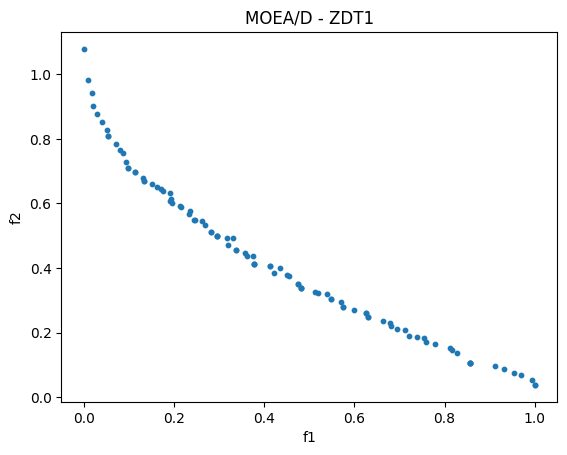

In [51]:
problem = get_problem("zdt1")

X, F = moead(problem, N=100, T=20, delta=0.7, max_gen=1000)

print(F[:10])   # show first 10 objective values

import matplotlib.pyplot as plt

plt.scatter(F[:, 0], F[:, 1], s=10)
plt.xlabel("f1")
plt.ylabel("f2")
plt.title("MOEA/D - ZDT1")
plt.show()

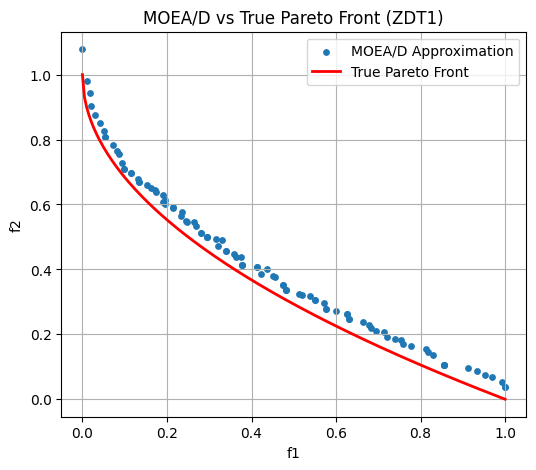

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Your result (already computed)
# F = output from MOEA/D

# True Pareto front
f1_true = np.linspace(0, 1, 200)
f2_true = 1 - np.sqrt(f1_true)

# Plot
plt.figure(figsize=(6,5))

# Your solutions
plt.scatter(F[:, 0], F[:, 1], s=15, label="MOEA/D Approximation")

# True front
plt.plot(f1_true, f2_true, 'r-', linewidth=2, label="True Pareto Front")

plt.xlabel("f1")
plt.ylabel("f2")
plt.title("MOEA/D vs True Pareto Front (ZDT1)")
plt.legend()
plt.grid(True)

plt.show()